<div style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;background:#0d1b2a;border-radius:10px;padding:18px 22px;color:#e6edf3;">
  <div style="display:flex;align-items:center;gap:12px;">
    <div style="width:6px;height:36px;background:#3fb950;border-radius:3px;flex:none;"></div>
    <div>
      <div style="font-size:11px;letter-spacing:2px;color:#8b98a5;">NOTEBOOK 05</div>
      <div style="font-size:21px;font-weight:700;line-height:1.15;">Regime Tracking</div>
    </div>
  </div>
  <div style="font-size:13px;color:#a9b4c0;margin-top:9px;">Stocks are not permanently attached to a group. Track one stock through correlation space over time and watch it detach and return. This is what motivates the model's detachment features.</div>
</div>

**Why this matters.** A pairs trade assumes a stable relationship. The trades
that lose are the ones where the relationship **breaks**: one stock leaves its
usual group and stops tracking its partner. If we can see that happening, we can
build features that warn the model.

**Method.** In each rolling window, describe every stock by its vector of
correlations to all other stocks (its *correlation profile*). Fit a single 2D
PCA on every window's profiles together, so the map's axes mean the same thing
across time and a stock's **position can be tracked**, not just compared. A
stock that stays in its sector cluster sits still; one whose links break drifts
away and (often) comes back.

> Pick any ticker via `TICKER`. Where its links to its sector break down, it
> drifts away in the map and (often) returns. These episodes occur naturally in
> real markets.

In [ ]:
import sys, os

from google.colab import drive
drive.mount('/content/drive')

# Function to find the project root containing the 'src' directory
def find_project_root():
    # List of potential base directories to search
    # Add current working directory and its parent directories to search paths
    _current_path = os.path.abspath(os.getcwd()) # This is typically /content in Colab
    potential_base_dirs = []
    _temp_path = _current_path
    while True:
        potential_base_dirs.append(_temp_path)
        if _temp_path == os.path.dirname(_temp_path): # Reached filesystem root '/'
            break
        _temp_path = os.path.dirname(_temp_path)

    # Also add the mounted Google Drive path as a potential base
    potential_base_dirs.append('/content/drive/MyDrive')

    for base_dir in potential_base_dirs:
        if not os.path.exists(base_dir):
            continue
        # Walk through the directories to find 'src'
        for dirpath, dirnames, filenames in os.walk(base_dir):
            if 'src' in dirnames:
                # Found a 'src' directory, the project root is its parent
                # For example, if src is found in /path/to/project/src,
                # then /path/to/project is the root.
                _project_root = dirpath
                return _project_root
    return None

_project_root = find_project_root()

if _project_root:
    # Only add to sys.path if it's not already there
    if _project_root not in sys.path:
        sys.path.insert(0, _project_root)
    print(f"Project root added to sys.path: {_project_root}")
else:
    print("Warning: 'src' directory not found in expected locations. Please ensure your project structure is correct or manually add the path to 'src' to sys.path.")


import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.config import CONFIG
from src.plotting import set_style, save_fig
set_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Data source: live Yahoo Finance via yfinance.
SOURCE = "yfinance"

In [2]:
from src.data import load_prices
from src import regime
prices, source = load_prices(source=SOURCE)
emb = regime.rolling_embeddings(prices)            # tidy: ticker, date, x, y, sector
print(f'source={source} | windows={emb.date.nunique()} | points={len(emb)}')
emb.head()

source=cache | windows=48 | points=2160


,x,y,ticker,date,sector
0,0.927625,-0.263477,AAPL,2018-07-03,Tech
1,0.416042,-0.280457,ABBV,2018-07-03,Health
2,1.276248,-0.206474,ADBE,2018-07-03,Tech
3,0.492374,0.021772,AMD,2018-07-03,Tech
4,0.747527,-0.086589,AMZN,2018-07-03,Consumer


### The map: where the sectors sit (final window)

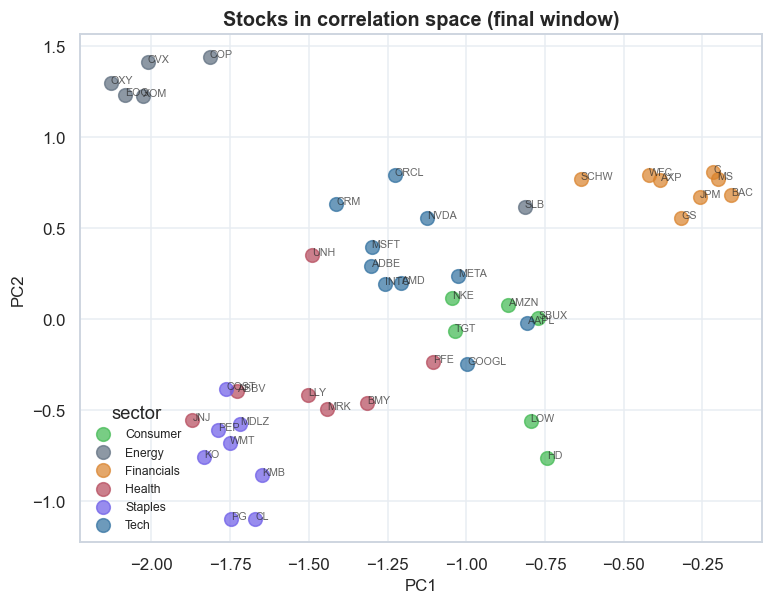

In [3]:
last = emb['date'].max(); snap = emb[emb.date==last]
colors = {'Tech':'#2f6f9f','Financials':'#d9822b','Health':'#b5495b','Consumer':'#3fb950','Staples':'#6c5ce7','Energy':'#5d6d7e'}
fig, ax = plt.subplots(figsize=(8,6))
for sec, gs in snap.groupby('sector'):
    ax.scatter(gs.x, gs.y, s=80, alpha=.7, color=colors.get(sec), label=sec)
    for _, r in gs.iterrows(): ax.annotate(r.ticker, (r.x, r.y), fontsize=7, alpha=.7)
ax.set_title('Stocks in correlation space (final window)'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(title='sector', fontsize=8); save_fig(fig,'regime_map_snapshot.png'); plt.show()

### Tracking one stock over time

The path of `LOW`, coloured from dark (earlier) to bright (later). During the planted break it leaves the Consumer cluster and then returns.

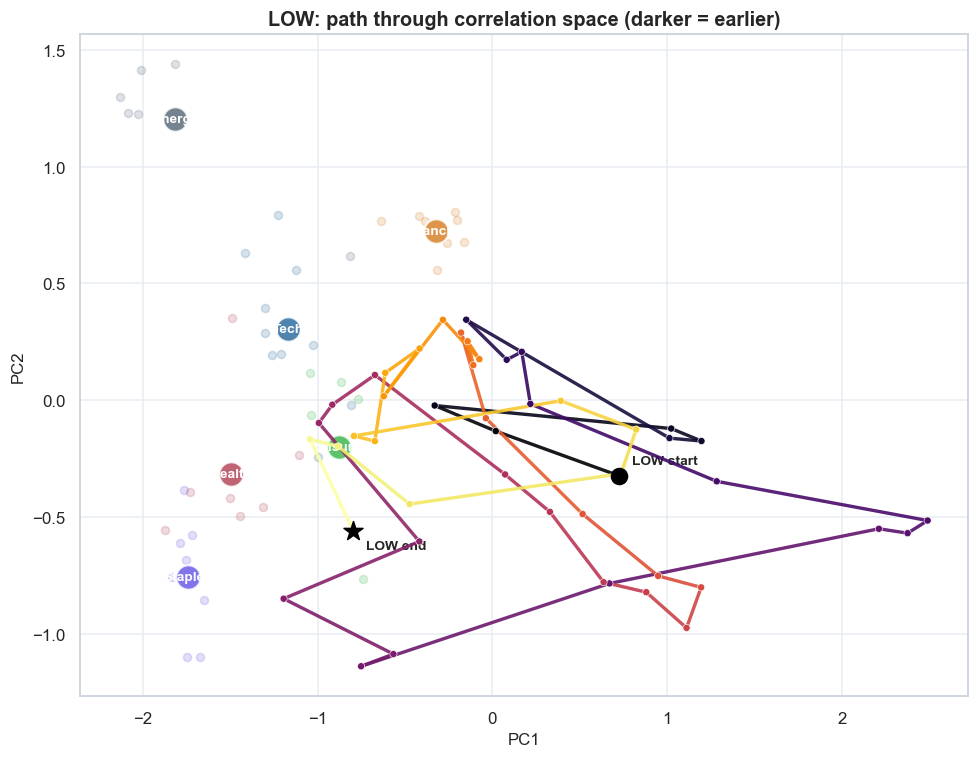

In [4]:
TICKER = 'LOW'
regime.plot_trajectory(emb, TICKER, 'regime_trajectory.png'); plt.show()

### A crisp read-out: distance from its own group

Distance from `LOW` to the centroid of its sector in each window. It rises when the stock detaches and falls when it rejoins.

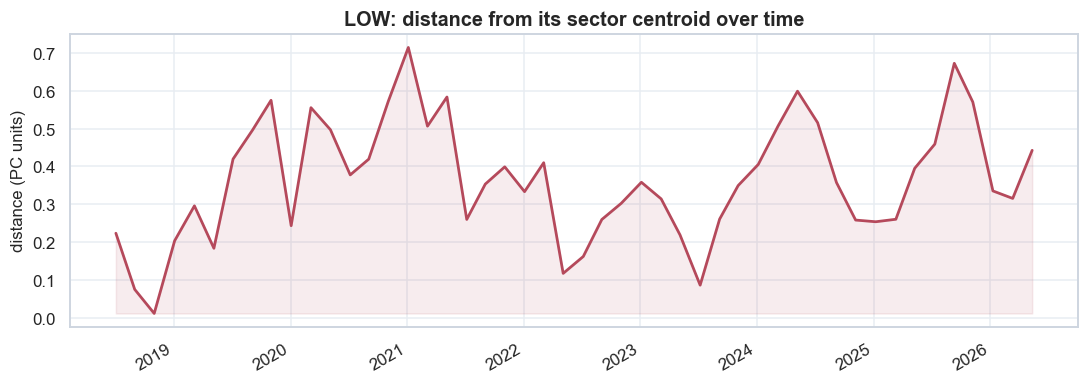

In [5]:
dist = regime.sector_centroid_distance(emb, TICKER)
breaks = None
regime.plot_distance_over_time(dist, TICKER, 'regime_distance.png', breaks=breaks); plt.show()

### Corroboration with raw correlations

No embedding needed: `LOW`'s rolling correlation to its own sector vs another sector. When it detaches, the home-sector correlation drops.

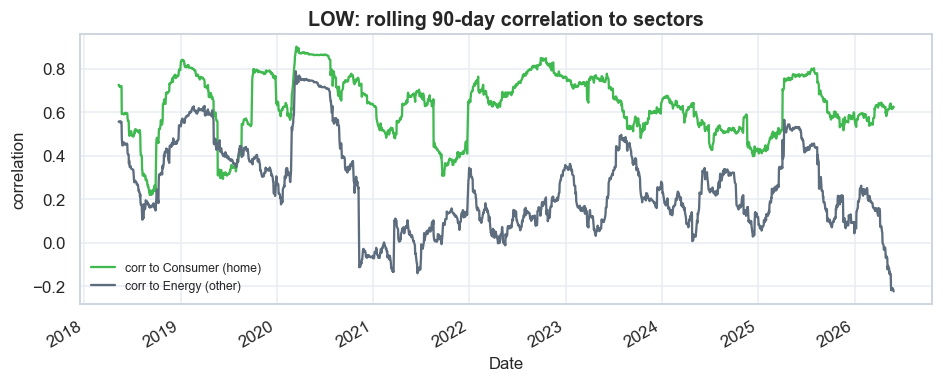

In [6]:
rets = np.log(prices).diff().dropna()
home = [t for t in SECTORS if sector_of(t)==sector_of(TICKER) and t!=TICKER]
away = [t for t in SECTORS if sector_of(t)=='Energy']
cc = rets[TICKER].rolling(90).corr(rets[home].mean(axis=1))
ce = rets[TICKER].rolling(90).corr(rets[away].mean(axis=1))
fig, ax = plt.subplots(figsize=(10,3.6))
cc.plot(ax=ax, label=f'corr to {sector_of(TICKER)} (home)', color='#3fb950')
ce.plot(ax=ax, label='corr to Energy (other)', color='#5d6d7e')
if breaks: ax.axvspan(*breaks, color='#9aa7b4', alpha=.18, label='planted break')
ax.set_title(f'{TICKER}: rolling 90-day correlation to sectors'); ax.set_ylabel('correlation'); ax.legend(fontsize=8)
save_fig(fig,'regime_corr_sectors.png'); plt.show()

### From visualization to features

The same dynamics are encoded as model features in `02_preprocessing`:

- **`corr_change`** = recent (60d) minus baseline (252d) correlation. Goes
  negative exactly when a stock starts detaching.
- **`comembership`** = share of recent windows the pair stayed correlated. Falls
  during a break.
- **`coint_recent_pvalue`** = local cointegration test on a trailing window. Rises
  (relationship no longer stationary) during a break.
- **`mom_rel`**, **`sector_dispersion`** = relative momentum and sector stress,
  which pick up rotations that precede breaks.

The ablation in `03_modeling` shows these features improve the model: they let it
distrust extreme events that occur while a relationship is breaking, which are
the ones least likely to revert.